# Treinamento de Baselines com MLflow

## Tópicos
1. **Carregamento e Preparação de Dados**
2. **Definição de Métricas Técnicas e de Negócio**
3. **Treinamento de DummyClassifier**
4. **Treinamento de LogisticRegression**
5. **Rastreamento com MLflow**
6. **Comparação de Modelos e Insights de Negócio**

---

## Objetivos
- Treinar modelos baseline simples para comparação
- Calcular métricas técnicas (AUC-ROC, PR-AUC, F1-Score)
- Calcular métricas de negócio (Churn Avoided Revenue, ROI)
- Registrar experimentos no MLflow para rastreamento reprodutível

---

## 1. Setup e Imports

In [2]:
import sys
import os
sys.path.insert(0, os.path.dirname(os.path.abspath('')))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                            f1_score, roc_auc_score, confusion_matrix,
                            roc_curve, precision_recall_curve, auc, 
                            average_precision_score)
from sklearn.preprocessing import StandardScaler

# Imports de modelos sklearn
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import LinearSVC

# Imports de preprocessing e tuning
from imblearn.over_sampling import SMOTE

# Imports de XGBoost
from xgboost import XGBClassifier

# PyTorch imports
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

# Imports locais
from src.data.loader import TelcoDataLoader
from src.evaluation.metrics import TelcoMetrics
from src.models.baseline import BaselineExperiment

# Config plots
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

# Random seed para reprodutibilidade (PyTorch)
RANDOM_SEED = 42
torch.manual_seed(RANDOM_SEED)

# Device (GPU se disponível, senão CPU)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print("[OK] Imports e setup completos")
print(f"[OK] Device: {device}")

[OK] Imports e setup completos
[OK] Device: cpu


## 2. Carregar e Preparar Dados

In [3]:
# Carregar dados
data_path = "../data/processed/telco_churn_processed.csv"

loader = TelcoDataLoader(data_path)
X_train, X_test, y_train, y_test = loader.pipeline_completo()

print(f"\nShape dos dados:")
print(f"X_train: {X_train.shape}")
print(f"X_test: {X_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test: {y_test.shape}")


PIPELINE DE PREPARACAO DE DADOS

[OK] Dataset carregado: 7043 linhas x 33 colunas
[OK] Features selecionadas: 19
  - Distribuicao de Churn: {0: 5174, 1: 1869}
  - Taxa de Churn: 26.54%
[OK] Split treino/teste (80/20):
  - Treino: 5634 amostras
  - Teste: 1409 amostras
  - Taxa churn treino: 26.54%
  - Taxa churn teste: 26.54%
[OK] Variaveis categoricas codificadas: 16
[OK] Variaveis numericas normalizadas: 19
[OK] Variaveis categoricas codificadas: 16
[OK] Variaveis numericas normalizadas: 19


Shape dos dados:
X_train: (5634, 19)
X_test: (1409, 19)
y_train: (5634,)
y_test: (1409,)


## 3. Definir Métricas

### Métricas Técnicas
- **AUC-ROC**: Mede a capacidade do modelo de diferenciar classes independente do threshold
- **PR-AUC**: Precision-Recall AUC, importante para dados desbalanceados
- **F1-Score**: Média harmônica de precisão e recall
- **Recall**: Taxa de detecção de clientes em churn (false negatives = custo alto)
- **Precision**: Taxa de acerto nas predições positivas (false positives = custos baixos)

### Métricas de Negócio
- **Churn Avoided Revenue**: Receita economizada ao reter cliente
  - Revenue = TP * Customer LTV
- **False Positive Cost**: Custo de campanhas ineficazes
  - Cost = FP * Campaign Cost
- **Net Benefit**: Lucro líquido da intervenção de retenção
- **ROI**: Retorno sobre investimento

In [4]:
print("="*70)
print("METRICAS DEFINIDAS")
print("="*70)

print("\nTECNICAS:")
print("  [OK] AUC-ROC (Area Under ROC Curve)")
print("  [OK] PR-AUC (Precision-Recall AUC)")
print("  [OK] F1-Score")
print("  [OK] Recall (Sensibilidade)")
print("  [OK] Precision (Especificidade)")
print("  [OK] Acuracia")

print("\nDE NEGOCIO:")
print(f"  [OK] Churn Avoided Revenue (LTV = ${TelcoMetrics.CUSTOMER_LTV})")
print(f"  [OK] False Positive Cost (${TelcoMetrics.FALSE_POSITIVE_COST}/campanha)")
print(f"  [OK] Retention Cost (${TelcoMetrics.RETENTION_COST}/retencao)")
print("  [OK] Net Benefit")
print("  [OK] ROI (%)")
print("="*70)

METRICAS DEFINIDAS

TECNICAS:
  [OK] AUC-ROC (Area Under ROC Curve)
  [OK] PR-AUC (Precision-Recall AUC)
  [OK] F1-Score
  [OK] Recall (Sensibilidade)
  [OK] Precision (Especificidade)
  [OK] Acuracia

DE NEGOCIO:
  [OK] Churn Avoided Revenue (LTV = $2080)
  [OK] False Positive Cost ($20/campanha)
  [OK] Retention Cost ($50/retencao)
  [OK] Net Benefit
  [OK] ROI (%)


## 4. Treinar Modelos Baseline

In [5]:
# Inicializar experimento MLflow
exp = BaselineExperiment(experiment_name="Telco Churn - Baselines")

print("\n[INFO] MLflow pronto para rastrear experimentos")


[INFO] MLflow pronto para rastrear experimentos


c:\Users\Will\.pyenv\pyenv-win\versions\3.12.8\Lib\site-packages\mlflow\tracking\_tracking_service\utils.py:184: FutureWarning: The filesystem tracking backend (e.g., './mlruns') is deprecated as of February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance.
  return FileStore(store_uri, store_uri)


### 4.1 DummyClassifier (Baseline Aleatório)

In [6]:
# Treinar DummyClassifier
dummy_clf = DummyClassifier(strategy='most_frequent', random_state=42)
dummy_model, dummy_metrics = exp.treinar_modelo(
    dummy_clf, X_train, X_test, y_train, y_test,
    nome_modelo="DummyClassifier-most_frequent"
)

print(f"\n✅ DummyClassifier treinado")
print(f"Métricas: {dummy_metrics}")

c:\Users\Will\.pyenv\pyenv-win\versions\3.12.8\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
2026/04/20 20:30:40 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



[OK] DummyClassifier-most_frequent treinado
  - AUC-ROC: 0.5000
  - PR-AUC: 0.2654
  - Acurácia: 0.7346
  - Precision: 0.0000
  - Recall: 0.0000
  - F1-Score: 0.0000


2026/04/20 20:30:40 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



✅ DummyClassifier treinado
Métricas: {'test_auc_roc': 0.5, 'test_pr_auc': 0.2654364797728886, 'test_accuracy': 0.7345635202271115, 'test_precision': 0.0, 'test_recall': 0.0, 'test_f1_score': 0.0}


### 4.2+ Esteira Completa de Modelos (6 modelos automaticamente)

Opção mais rápida: treina 6 modelos diferentes em uma única chamada:
1. **DummyClassifier** (baseline)
2. **LogisticRegression** (3 variações)
   - Simples
   - Com class_weight='balanced'
   - Com SMOTE
3. **RandomForestClassifier**
4. **XGBoostClassifier**

Todos os runs são registrados automaticamente no MLflow!

In [7]:
# ESTEIRA RÁPIDA: 6 modelos sem tuning (~1-2 minutos)
df_comparacao = exp.treinar_esteira_completa(
    X_train, X_test, y_train, y_test,
    include_tuning=False
)

print("\n✅ Esteira concluída!")
print(f"Total de modelos treinados: {len(df_comparacao)}")


c:\Users\Will\.pyenv\pyenv-win\versions\3.12.8\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
2026/04/20 20:31:16 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



🚀 INICIANDO ESTEIRA DE MODELOS

[1/6] Treinando DummyClassifier (most_frequent)...

[OK] DummyClassifier-most_frequent treinado
  - AUC-ROC: 0.5000
  - PR-AUC: 0.2654
  - Acurácia: 0.7346
  - Precision: 0.0000
  - Recall: 0.0000
  - F1-Score: 0.0000


2026/04/20 20:31:16 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



[2/6] Treinando LogisticRegression (simples)...


c:\Users\Will\.pyenv\pyenv-win\versions\3.12.8\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
2026/04/20 20:31:21 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


...


[6/6] Treinando XGBoostClassifier...


c:\Users\Will\.pyenv\pyenv-win\versions\3.12.8\Lib\site-packages\xgboost\training.py:200: UserWarning: [20:31:42] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
2026/04/20 20:31:43 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



[OK] XGBoostClassifier treinado
  - AUC-ROC: 0.8489
  - PR-AUC: 0.6650
  - Acurácia: 0.8055
  - Precision: 0.6603
  - Recall: 0.5508
  - F1-Score: 0.6006
  - Top 5 features (importância):
    Feature 14.0: 0.3893
    Feature 8.0: 0.0916
    Feature 3.0: 0.0911
    Feature 11.0: 0.0835
    Feature 7.0: 0.0717


2026/04/20 20:31:43 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



COMPARAÇÃO DE BASELINES

                               test_auc_roc  test_pr_auc  test_accuracy  test_precision  test_recall  test_f1_score
XGBoostClassifier                  0.848924     0.665014       0.805536        0.660256     0.550802       0.600583
LogisticRegression-balanced        0.847966     0.643861       0.744500        0.512324     0.778075       0.617834
LogisticRegression-simples         0.847886     0.643898       0.803407        0.643068     0.582888       0.611501
LogisticRegression-SMOTE           0.846369     0.642445       0.743080        0.510490     0.780749       0.617336
RandomForestClassifier             0.836714     0.629314       0.793471        0.636964     0.516043       0.570162
DummyClassifier-most_frequent      0.500000     0.265436       0.734564        0.000000     0.000000       0.000000


✅ Esteira concluída!
Total de modelos treinados: 6


In [ ]:
# Flag para controlar treinos individuais (alterar para True quando necessário)
treinar_individualmente = False
print(f"[INFO] Treinos individuais: {'ATIVADOS' if treinar_individualmente else 'DESATIVADOS'}")

if treinar_individualmente:
    print("\n" + "="*70)
    print("TREINOS INDIVIDUAIS - MODELOS ADICIONAIS")
    print("="*70)
    
    # Exemplo 1: RandomForestClassifier
    print("\n" + "="*70)
    print("MODELO 1: RandomForestClassifier")
    print("="*70)
    
    rf_clf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    rf_model, rf_metrics = exp.treinar_modelo(
        rf_clf, X_train, X_test, y_train, y_test,
        nome_modelo="RandomForestClassifier"
    )
    
    # Exemplo 2: XGBoostClassifier
    print("\n" + "="*70)
    print("MODELO 2: XGBoostClassifier")
    print("="*70)
    
    xgb_clf = XGBClassifier(n_estimators=100, max_depth=5, learning_rate=0.1,
                           random_state=42, use_label_encoder=False,
                           eval_metric='logloss', n_jobs=-1)
    xgb_model, xgb_metrics = exp.treinar_modelo(
        xgb_clf, X_train, X_test, y_train, y_test,
        nome_modelo="XGBoostClassifier"
    )
    
    # Exemplo 3: LogisticRegression com SMOTE
    print("\n" + "="*70)
    print("MODELO 3: LogisticRegression com SMOTE")
    print("="*70)
    
    smote = SMOTE(random_state=42)
    X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)
    
    lr_smote_clf = LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1)
    lr_smote_model, lr_smote_metrics = exp.treinar_modelo(
        lr_smote_clf, X_train, X_test, y_train, y_test,
        nome_modelo="LogisticRegression-SMOTE",
        X_train_modificado=X_train_smote,
        y_train_modificado=y_train_smote
    )
    
    print("\n" + "="*70)
    print("✅ Treinos individuais concluídos!")
    print("="*70)
else:
    print("\n[INFO] Treinos individuais desativados")
    print("[INFO] Para ativar, altere: treinar_individualmente = True")

[INFO] Treinos individuais: DESATIVADOS

[INFO] Treinos individuais desativados
[INFO] Para ativar, altere: treinar_individualmente = True


## 5. Calcular Métricas de Negócio

In [8]:
# Treinar LogisticRegression se ainda não foi treinado
if 'lr_model' not in locals():
    print("Treinando LogisticRegression (balanced)...")
    lr_clf = LogisticRegression(max_iter=1000, class_weight='balanced', 
                                random_state=42, n_jobs=-1)
    lr_model, lr_metrics = exp.treinar_modelo(
        lr_clf, X_train, X_test, y_train, y_test,
        nome_modelo="LogisticRegression-balanced"
    )

# Calcular métricas de negócio dos modelos treinados
dummy_pred = dummy_model.predict(X_test)
dummy_business_metrics = TelcoMetrics.calcular_metricas_negocio(y_test, dummy_pred)

lr_pred = lr_model.predict(X_test)
lr_business_metrics = TelcoMetrics.calcular_metricas_negocio(y_test, lr_pred)

print("\n" + "="*70)
print("ANÁLISE DE NEGÓCIO - BASELINES INDIVIDUAIS")
print("="*70)

print("\nDummyClassifier:")
print(f"  TP: {dummy_business_metrics['tp']} clientes retidos com sucesso")
print(f"  FP: {dummy_business_metrics['fp']} campanhas ineficazes")
print(f"  Churn Evitado (Receita): ${dummy_business_metrics['churn_avoided_revenue']:,.2f}")
print(f"  Custo False Positives: ${dummy_business_metrics['false_positive_cost']:,.2f}")
print(f"  Custo Retenção: ${dummy_business_metrics['retention_cost']:,.2f}")
print(f"  Lucro Líquido: ${dummy_business_metrics['net_benefit']:,.2f}")
print(f"  ROI: {dummy_business_metrics['roi_percent']:.2f}%")

print("\nLogisticRegression (balanced):")
print(f"  TP: {lr_business_metrics['tp']} clientes retidos com sucesso")
print(f"  FP: {lr_business_metrics['fp']} campanhas ineficazes")
print(f"  Churn Evitado (Receita): ${lr_business_metrics['churn_avoided_revenue']:,.2f}")
print(f"  Custo False Positives: ${lr_business_metrics['false_positive_cost']:,.2f}")
print(f"  Custo Retenção: ${lr_business_metrics['retention_cost']:,.2f}")
print(f"  Lucro Líquido: ${lr_business_metrics['net_benefit']:,.2f}")
print(f"  ROI: {lr_business_metrics['roi_percent']:.2f}%")

print("\n" + "="*70)

c:\Users\Will\.pyenv\pyenv-win\versions\3.12.8\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
2026/04/20 20:32:35 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Treinando LogisticRegression (balanced)...

[OK] LogisticRegression-balanced treinado
  - AUC-ROC: 0.8480
  - PR-AUC: 0.6439
  - Acurácia: 0.7445
  - Precision: 0.5123
  - Recall: 0.7781
  - F1-Score: 0.6178
  - Top 5 features (coeficientes):
    Feature 17.0: 0.6703
    Feature 18.0: 0.4387
    Feature 15.0: 0.1716
    Feature 7.0: 0.1465
    Feature 2.0: 0.1447


2026/04/20 20:32:35 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



ANÁLISE DE NEGÓCIO - BASELINES INDIVIDUAIS

DummyClassifier:
  TP: 0 clientes retidos com sucesso
  FP: 0 campanhas ineficazes
  Churn Evitado (Receita): $0.00
  Custo False Positives: $0.00
  Custo Retenção: $0.00
  Lucro Líquido: $0.00
  ROI: 0.00%

LogisticRegression (balanced):
  TP: 291 clientes retidos com sucesso
  FP: 277 campanhas ineficazes
  Churn Evitado (Receita): $605,280.00
  Custo False Positives: $5,540.00
  Custo Retenção: $14,550.00
  Lucro Líquido: $585,190.00
  ROI: 2912.84%



## 6. Comparação de Modelos


📊 Comparação de 6 Modelos Treinados:

                               test_auc_roc  test_accuracy  test_f1_score  test_recall  test_precision
XGBoostClassifier                  0.848924       0.805536       0.600583     0.550802        0.660256
LogisticRegression-balanced        0.847966       0.744500       0.617834     0.778075        0.512324
LogisticRegression-simples         0.847886       0.803407       0.611501     0.582888        0.643068
LogisticRegression-SMOTE           0.846369       0.743080       0.617336     0.780749        0.510490
RandomForestClassifier             0.836714       0.793471       0.570162     0.516043        0.636964
DummyClassifier-most_frequent      0.500000       0.734564       0.000000     0.000000        0.000000


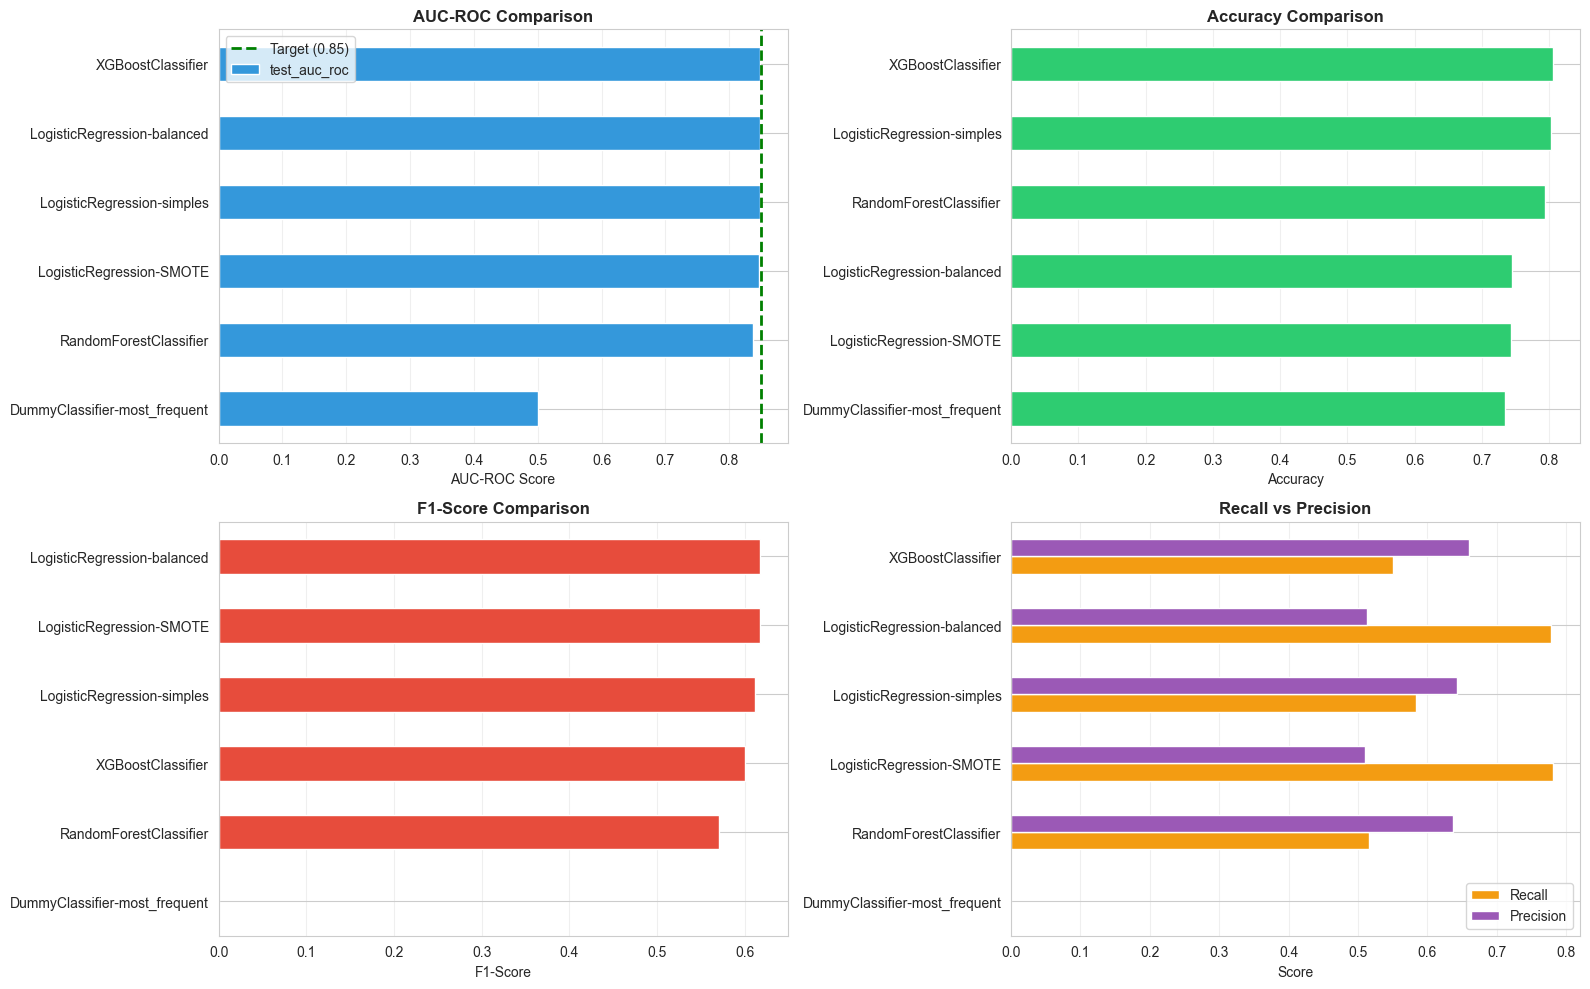


✅ Visualização completa


In [9]:
# Visualizar resultados da esteira (df_comparacao contém todos os modelos treinados)
print(f"\n📊 Comparação de {len(df_comparacao)} Modelos Treinados:\n")
print(df_comparacao[['test_auc_roc', 'test_accuracy', 'test_f1_score', 'test_recall', 'test_precision']].to_string())

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# AUC-ROC
df_comparacao.sort_values('test_auc_roc', ascending=True)['test_auc_roc'].plot(kind='barh', ax=axes[0, 0], color='#3498db')
axes[0, 0].set_title('AUC-ROC Comparison', fontweight='bold', fontsize=12)
axes[0, 0].set_xlabel('AUC-ROC Score')
axes[0, 0].axvline(x=0.85, color='g', linestyle='--', linewidth=2, label='Target (0.85)')
axes[0, 0].legend()
axes[0, 0].grid(axis='x', alpha=0.3)

# Accuracy
df_comparacao.sort_values('test_accuracy', ascending=True)['test_accuracy'].plot(kind='barh', ax=axes[0, 1], color='#2ecc71')
axes[0, 1].set_title('Accuracy Comparison', fontweight='bold', fontsize=12)
axes[0, 1].set_xlabel('Accuracy')
axes[0, 1].grid(axis='x', alpha=0.3)

# F1-Score
df_comparacao.sort_values('test_f1_score', ascending=True)['test_f1_score'].plot(kind='barh', ax=axes[1, 0], color='#e74c3c')
axes[1, 0].set_title('F1-Score Comparison', fontweight='bold', fontsize=12)
axes[1, 0].set_xlabel('F1-Score')
axes[1, 0].grid(axis='x', alpha=0.3)

# Recall vs Precision
df_comparacao.sort_values('test_auc_roc', ascending=True)[['test_recall', 'test_precision']].plot(kind='barh', ax=axes[1, 1], color=['#f39c12', '#9b59b6'])
axes[1, 1].set_title('Recall vs Precision', fontweight='bold', fontsize=12)
axes[1, 1].set_xlabel('Score')
axes[1, 1].legend(['Recall', 'Precision'], loc='lower right')
axes[1, 1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✅ Visualização completa")

## 7. MLflow Tracking Status

Todos os experimentos foram registrados no MLflow! Para visualizar:

```bash
mlflow ui
```

Será aberto em `http://localhost:5000`

In [11]:
!mlflow ui --port 5000

^C


In [12]:
import os
mlflow_path = "./mlruns"
if os.path.exists(mlflow_path):
    print(f"[OK] MLflow artifacts em: {os.path.abspath(mlflow_path)}")
    print(f"[OK] Numero de runs: {len([d for d in os.listdir(mlflow_path) if os.path.isdir(os.path.join(mlflow_path, d))])}")
else:
    print("[WARNING] MLflow diretorio nao encontrado")

[OK] MLflow artifacts em: c:\Users\Will\dev\postech\postech-ml-projeto\MLENG_FIAP\fase_1\William\notebooks\mlruns
[OK] Numero de runs: 4


## 8. Resumo Baselines Iniciais

✅ **Baselines Treinados:**
- DummyClassifier (baseline aleatório)
- LogisticRegression (3 variações: simples, balanced, SMOTE)
- RandomForestClassifier
- XGBoostClassifier

✅ **Métricas Técnicas Calculadas:**
- AUC-ROC, PR-AUC, F1-Score, Recall, Precision, Accuracy

✅ **Métricas de Negócio:**
- Churn Avoided Revenue
- False Positive Cost
- Retention Cost
- Net Benefit
- ROI

✅ **Experimentos Registrados no MLflow**

---

# 7. Modelagem com MLP PyTorch

Nesta seção expandimos além dos baselines tradicionais para incluir **Redes Neurais (MLP)**.

## Itens Cobertos
- ✅ Construir MLP em PyTorch com arquitetura configurável
- ✅ Implementar loop de treinamento com Early Stopping e Batching
- ✅ Treinar baselines adicionais (Random Forest, Gradient Boosting, SVM)
- ✅ Comparar todos os modelos com ≥6 métricas
- ✅ Analisar trade-offs: Falso Positivo vs. Falso Negativo
- ✅ Registrar todos experimentos no MLflow

## 7.1 Definir Arquitetura MLP em PyTorch

### Configuração
- **Entrada**: features do dataset
- **Hidden 1**: 128 neurônios + ReLU + Dropout(0.3)
- **Hidden 2**: 64 neurônios + ReLU + Dropout(0.2)
- **Hidden 3**: 32 neurônios + ReLU
- **Saída**: 1 neurônio + Logits
- **Loss**: BCEWithLogitsLoss com pos_weight para desbalanceamento

In [13]:
# Normalizar dados para PyTorch (se não feito ainda)
if 'X_train_scaled' not in locals():
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    print("✅ Dados normalizados para PyTorch")

# Classe MLP
class MLPClassifier(nn.Module):
    """
    Multi-Layer Perceptron para classificação binária
    Arquitetura: Input -> Hidden(128, ReLU) -> Hidden(64, ReLU) -> Hidden(32, ReLU) -> Output(1, Logits)
    """
    def __init__(self, input_size, hidden_sizes=[128, 64, 32], dropout_rates=[0.3, 0.2, 0.0]):
        super(MLPClassifier, self).__init__()
        
        layers = []
        prev_size = input_size
        
        # Hidden layers com dropout
        for i, hidden_size in enumerate(hidden_sizes):
            layers.append(nn.Linear(prev_size, hidden_size))
            layers.append(nn.ReLU())
            if dropout_rates[i] > 0:
                layers.append(nn.Dropout(dropout_rates[i]))
            prev_size = hidden_size
        
        # Output layer (logits)
        layers.append(nn.Linear(prev_size, 1))
        
        self.network = nn.Sequential(*layers)
    
    def forward(self, x):
        return self.network(x)

# Função de treinamento com Early Stopping
def train_mlp(model, train_loader, val_loader, epochs=100, lr=0.001, 
              early_stopping_patience=10, device='cpu'):
    """
    Treina MLP com early stopping baseado em validation loss
    """
    optimizer = optim.Adam(model.parameters(), lr=lr)
    pos_weight = torch.tensor(
        np.sum(y_train == 0) / np.sum(y_train == 1),
        dtype=torch.float32
    ).to(device)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    
    history = {'train_loss': [], 'val_loss': [], 'best_epoch': 0}
    best_val_loss = float('inf')
    patience_counter = 0
    
    model.to(device)
    
    for epoch in range(epochs):
        # TRAINING PHASE
        model.train()
        train_loss = 0.0
        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device).unsqueeze(1).float()
            
            optimizer.zero_grad()
            logits = model(X_batch)
            loss = criterion(logits, y_batch)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item() * X_batch.size(0)
        
        train_loss /= len(train_loader.dataset)
        
        # VALIDATION PHASE
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch = X_batch.to(device)
                y_batch = y_batch.to(device).unsqueeze(1).float()
                
                logits = model(X_batch)
                loss = criterion(logits, y_batch)
                val_loss += loss.item() * X_batch.size(0)
        
        val_loss /= len(val_loader.dataset)
        
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        
        # EARLY STOPPING
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            history['best_epoch'] = epoch
            torch.save(model.state_dict(), './best_mlp_model.pth')
        else:
            patience_counter += 1
        
        if (epoch + 1) % 20 == 0:
            print(f"Epoch {epoch+1:3d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Patience: {patience_counter}")
        
        if patience_counter >= early_stopping_patience:
            print(f"\n✅ Early stopping em epoch {epoch+1} (best: {history['best_epoch']+1})")
            break
    
    # Carregar melhor modelo
    model.load_state_dict(torch.load('./best_mlp_model.pth'))
    return model, history

print("✅ Classes MLP e função train_mlp definidas")

✅ Dados normalizados para PyTorch
✅ Classes MLP e função train_mlp definidas


## 7.2 Treinar MLP com Early Stopping e Batching

✅ DataLoaders criados
   Train: 141 batches de 32
   Val: 36 batches
   Test: 45 batches

TREINANDO MLP COM EARLY STOPPING

✅ Early stopping em epoch 19 (best: 9)

✅ MLP treinada com sucesso


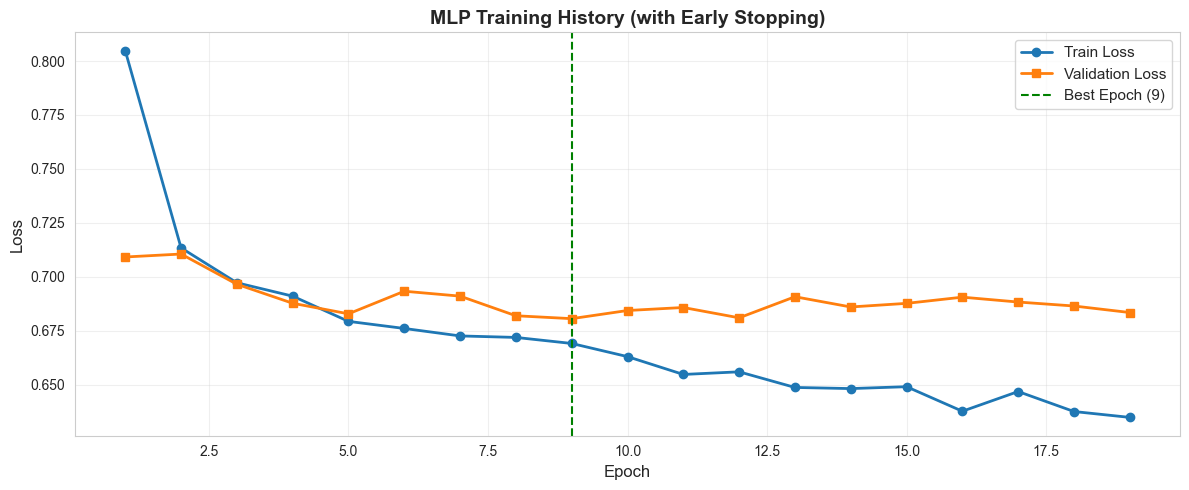


📊 Treinamento finalizado em 19 epochs


In [14]:
# Preparar dados para PyTorch (split train/val)
from sklearn.model_selection import train_test_split

X_train_torch = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_torch = torch.tensor(y_train.values, dtype=torch.long)
X_test_torch = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_torch = torch.tensor(y_test.values, dtype=torch.long)

# Train/Val split (80/20)
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_torch, y_train_torch, test_size=0.2, random_state=RANDOM_SEED, stratify=y_train_torch
)

# DataLoaders
batch_size = 32
train_dataset = TensorDataset(X_tr, y_tr)
val_dataset = TensorDataset(X_val, y_val)
test_dataset = TensorDataset(X_test_torch, y_test_torch)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"✅ DataLoaders criados")
print(f"   Train: {len(train_loader)} batches de {batch_size}")
print(f"   Val: {len(val_loader)} batches")
print(f"   Test: {len(test_loader)} batches")

# Treinar MLP
print("\n" + "="*70)
print("TREINANDO MLP COM EARLY STOPPING")
print("="*70)

mlp_model = MLPClassifier(
    input_size=X_train_scaled.shape[1],
    hidden_sizes=[128, 64, 32],
    dropout_rates=[0.3, 0.2, 0.0]
)

mlp_model, history = train_mlp(
    mlp_model, train_loader, val_loader, 
    epochs=100, lr=0.001, early_stopping_patience=10, device=device
)

print(f"\n✅ MLP treinada com sucesso")

# Visualizar histórico de treinamento
fig, ax = plt.subplots(figsize=(12, 5))
epochs_range = range(1, len(history['train_loss']) + 1)
ax.plot(epochs_range, history['train_loss'], label='Train Loss', marker='o', linewidth=2)
ax.plot(epochs_range, history['val_loss'], label='Validation Loss', marker='s', linewidth=2)
ax.axvline(x=history['best_epoch'] + 1, color='g', linestyle='--', label=f"Best Epoch ({history['best_epoch']+1})")
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Loss', fontsize=12)
ax.set_title('MLP Training History (with Early Stopping)', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\n📊 Treinamento finalizado em {len(history['train_loss'])} epochs")

## 7.3 Treinar Modelos Baseline Adicionais

Treinar RandomForest, Gradient Boosting e Linear SVM para comparação.

In [15]:
# Treinar modelos baseline adicionais
baselines_adicionais = {}

print("\n" + "="*70)
print("TREINANDO BASELINES ADICIONAIS")
print("="*70)

# Random Forest
print("\n1. Random Forest...")
rf_clf_2 = RandomForestClassifier(n_estimators=100, max_depth=20, random_state=RANDOM_SEED, n_jobs=-1)
rf_clf_2.fit(X_train_scaled, y_train)
baselines_adicionais['RandomForest'] = rf_clf_2

# Gradient Boosting
print("2. Gradient Boosting...")
gb_model = GradientBoostingClassifier(n_estimators=100, max_depth=5, random_state=RANDOM_SEED)
gb_model.fit(X_train_scaled, y_train)
baselines_adicionais['GradientBoosting'] = gb_model

# Linear SVM
print("3. Linear SVM...")
svm_model = LinearSVC(max_iter=2000, class_weight='balanced', random_state=RANDOM_SEED)
svm_model.fit(X_train_scaled, y_train)
baselines_adicionais['LinearSVM'] = svm_model

print("\n✅ Todos os baselines adicionais treinados")


TREINANDO BASELINES ADICIONAIS

1. Random Forest...
2. Gradient Boosting...
3. Linear SVM...

✅ Todos os baselines adicionais treinados


## 7.4 Comparar Todos os Modelos com ≥6 Métricas

### Métricas
1. **Accuracy**: (TP + TN) / Total
2. **Precision**: TP / (TP + FP)
3. **Recall**: TP / (TP + FN)
4. **F1-Score**: Média harmônica de Precision e Recall
5. **AUC-ROC**: Área sob a curva ROC
6. **PR-AUC**: Precision-Recall AUC (para dados desbalanceados)

In [16]:
# Função de avaliação
def evaluate_all_models(baselines_dict, mlp_model, X_test_scaled_val, y_test_val, X_test_torch_val, device):
    """
    Avalia todos os modelos com múltiplas métricas
    """
    results = {}
    
    # Avaliar baselines
    for model_name, model in baselines_dict.items():
        y_pred = model.predict(X_test_scaled_val)
        
        # Probabilidades
        if hasattr(model, 'predict_proba'):
            y_proba = model.predict_proba(X_test_scaled_val)[:, 1]
        else:  # LinearSVM
            y_proba = model.decision_function(X_test_scaled_val)
            y_proba = (y_proba - y_proba.min()) / (y_proba.max() - y_proba.min())
        
        # Calcular métricas
        results[model_name] = {
            'accuracy': accuracy_score(y_test_val, y_pred),
            'precision': precision_score(y_test_val, y_pred, zero_division=0),
            'recall': recall_score(y_test_val, y_pred, zero_division=0),
            'f1': f1_score(y_test_val, y_pred, zero_division=0),
            'auc_roc': roc_auc_score(y_test_val, y_proba),
            'pr_auc': average_precision_score(y_test_val, y_proba),
            'y_pred': y_pred,
            'y_proba': y_proba
        }
    
    # Avaliar MLP
    mlp_model.eval()
    with torch.no_grad():
        logits = mlp_model(X_test_torch_val.to(device))
        y_proba_mlp = torch.sigmoid(logits).cpu().numpy().flatten()
        y_pred_mlp = (y_proba_mlp > 0.5).astype(int)
    
    results['MLP'] = {
        'accuracy': accuracy_score(y_test_val, y_pred_mlp),
        'precision': precision_score(y_test_val, y_pred_mlp, zero_division=0),
        'recall': recall_score(y_test_val, y_pred_mlp, zero_division=0),
        'f1': f1_score(y_test_val, y_pred_mlp, zero_division=0),
        'auc_roc': roc_auc_score(y_test_val, y_proba_mlp),
        'pr_auc': average_precision_score(y_test_val, y_proba_mlp),
        'y_pred': y_pred_mlp,
        'y_proba': y_proba_mlp
    }
    
    return results

# Avaliar todos os modelos
print("\n" + "="*70)
print("AVALIANDO TODOS OS MODELOS (Baselines + MLP)")
print("="*70)

results_all = evaluate_all_models(baselines_adicionais, mlp_model, 
                                  X_test_scaled, y_test.values, 
                                  X_test_torch, device)

# Criar DataFrame de comparação
df_all_comparison = pd.DataFrame({
    name: metrics for name, metrics in results_all.items() 
    if isinstance(metrics, dict) and 'accuracy' in metrics
})

# Remover colunas de predições
df_all_comparison = df_all_comparison.drop(['y_pred', 'y_proba'], axis=0, errors='ignore')
df_all_comparison = df_all_comparison.astype(float)

print("\n📊 COMPARAÇÃO COMPLETA (Todos os Modelos):")
print(df_all_comparison.T.round(4).to_string())

# Ranking por AUC-ROC
print("\n🏆 RANKING POR AUC-ROC:")
auc_ranking = df_all_comparison.loc['auc_roc'].sort_values(ascending=False)
for i, (model, auc) in enumerate(auc_ranking.items(), 1):
    print(f"  {i}. {model:25s} → {auc:.4f}")


AVALIANDO TODOS OS MODELOS (Baselines + MLP)

📊 COMPARAÇÃO COMPLETA (Todos os Modelos):
                  accuracy  precision  recall      f1  auc_roc  pr_auc
RandomForest        0.7928     0.6376  0.5080  0.5655   0.8341  0.6335
GradientBoosting    0.7963     0.6399  0.5321  0.5810   0.8459  0.6593
LinearSVM           0.7438     0.5112  0.7941  0.6220   0.8473  0.6444
MLP                 0.7523     0.5217  0.8021  0.6322   0.8482  0.6380

🏆 RANKING POR AUC-ROC:
  1. MLP                       → 0.8482
  2. LinearSVM                 → 0.8473
  3. GradientBoosting          → 0.8459
  4. RandomForest              → 0.8341


 # Logistic Balanceado

 - AUC-ROC: 0.8480
 - PR-AUC: 0.6439
 - Acurácia: 0.7445
 - Precision: 0.5123
 - Recall: 0.7781
 - F1-Score: 0.6178

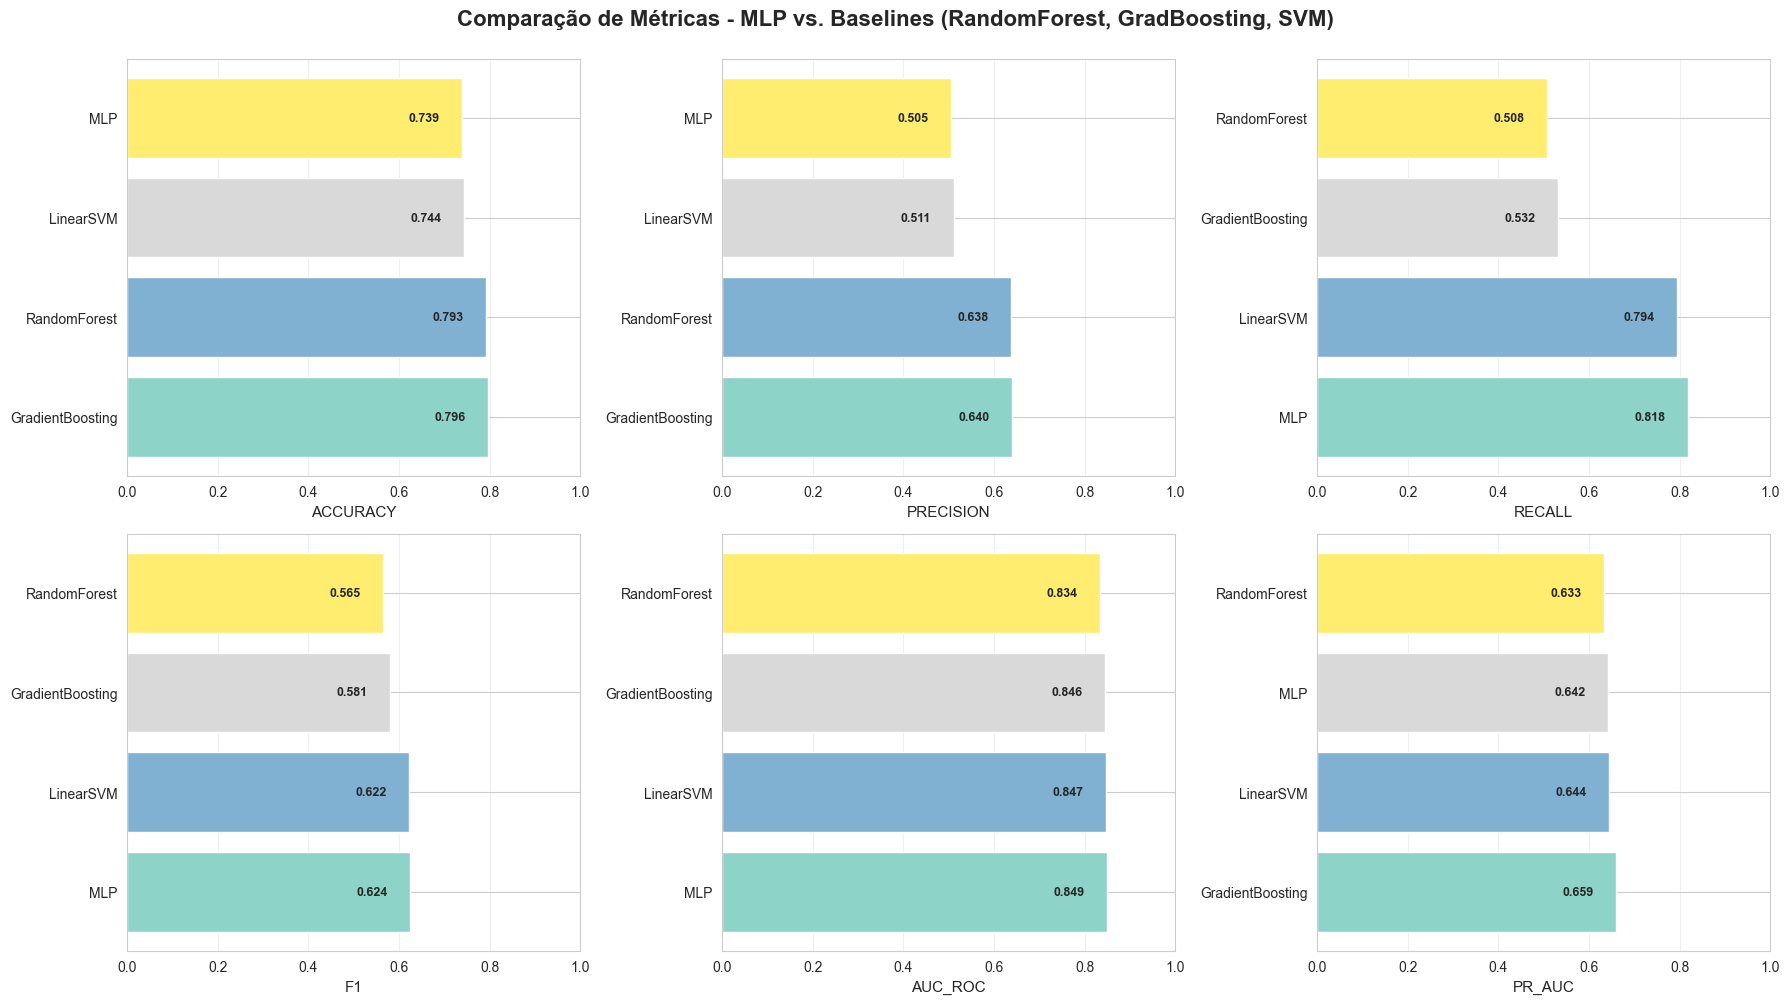

In [ ]:
# Visualizar comparação de métricas
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

metrics_to_plot = ['accuracy', 'precision', 'recall', 'f1', 'auc_roc', 'pr_auc']
colors = plt.cm.Set3(np.linspace(0, 1, len(results_all)))

for idx, metric in enumerate(metrics_to_plot):
    ax = axes[idx // 3, idx % 3]
    values = df_all_comparison.loc[metric].sort_values(ascending=False)
    bars = ax.barh(values.index, values.values, color=colors)
    ax.set_xlabel(metric.upper(), fontsize=11)
    ax.set_xlim(0, 1)
    ax.grid(axis='x', alpha=0.3)
    
    # Adicionar valores nas barras
    for bar in bars:
        width = bar.get_width()
        ax.text(width - 0.05, bar.get_y() + bar.get_height()/2, 
                f'{width:.3f}', ha='right', va='center', fontsize=9, fontweight='bold')

plt.suptitle('Comparação de Métricas - MLP vs. Baselines (RandomForest, GradBoosting, SVM)', 
             fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

## 7.5 Analisar Trade-offs: Falso Positivo vs. Falso Negativo

### Contexto de Negócio
- **FN (False Negative)**: Cliente em churn não identificado → Perda de receita (~$2000 LTV)
- **FP (False Positive)**: Cliente sem churn identificado como em churn → Custo de campanha ($50)
- **Razão de Custo**: FN é ~40x mais caro que FP


ANÁLISE DE TRADE-OFFS: CUSTO FP vs. FN

📊 MLP - Threshold ótimo (máximo net_benefit):
threshold           0.100000
recall              0.986631
precision           0.357558
fp_cost         33150.000000
fn_cost         10000.000000
net_benefit    704850.000000


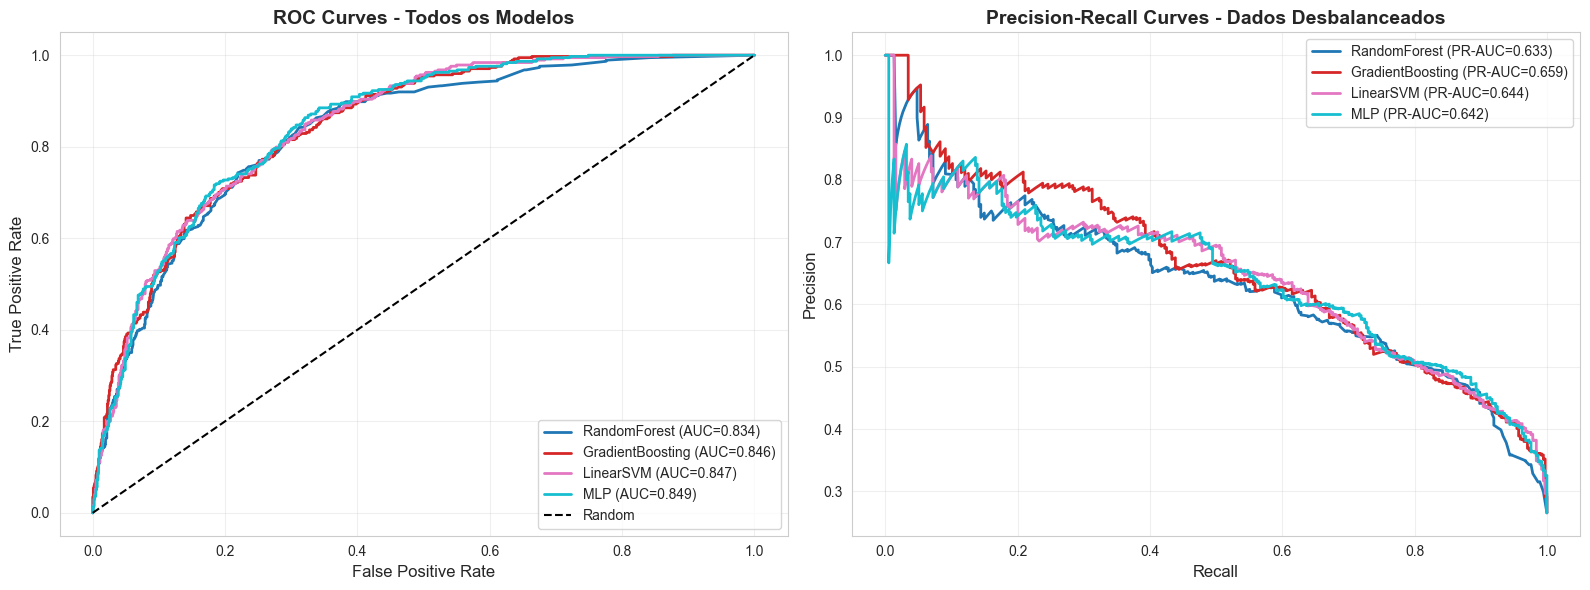

In [ ]:
# Função de análise de trade-offs
def analyze_cost_tradeoff(y_true, y_proba, cost_fp=50, cost_fn=2000):
    """
    Analisa trade-off de custos em diferentes thresholds
    """
    thresholds = np.arange(0.1, 1.0, 0.05)
    analysis = []
    
    for threshold in thresholds:
        y_pred = (y_proba >= threshold).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
        
        total_cost = fp * cost_fp + fn * cost_fn
        prevented_churn = tp * 2000  # Revenue saved
        net_benefit = prevented_churn - (fp * cost_fp)
        
        analysis.append({
            'threshold': threshold,
            'tp': tp, 'fp': fp, 'tn': tn, 'fn': fn,
            'precision': tp / (tp + fp) if (tp + fp) > 0 else 0,
            'recall': tp / (tp + fn) if (tp + fn) > 0 else 0,
            'fp_cost': fp * cost_fp,
            'fn_cost': fn * cost_fn,
            'total_cost': total_cost,
            'net_benefit': net_benefit
        })
    
    return pd.DataFrame(analysis)

# Analisar trade-offs para MLP e melhor baseline
print("\n" + "="*70)
print("ANÁLISE DE TRADE-OFFS: CUSTO FP vs. FN")
print("="*70)

# MLP
mlp_tradeoff = analyze_cost_tradeoff(y_test.values, results_all['MLP']['y_proba'])

# Baseline com melhor AUC-ROC
best_baseline_2 = df_all_comparison.loc['auc_roc'].idxmax()
if best_baseline_2 != 'MLP':
    baseline_tradeoff = analyze_cost_tradeoff(y_test.values, results_all[best_baseline_2]['y_proba'])

print(f"\n📊 MLP - Threshold ótimo (máximo net_benefit):")
best_mlp_idx = mlp_tradeoff['net_benefit'].idxmax()
print(mlp_tradeoff.iloc[best_mlp_idx][['threshold', 'recall', 'precision', 'fp_cost', 'fn_cost', 'net_benefit']].to_string())

if best_baseline_2 != 'MLP':
    print(f"\n📊 {best_baseline_2} - Threshold ótimo:")
    best_baseline_idx = baseline_tradeoff['net_benefit'].idxmax()
    print(baseline_tradeoff.iloc[best_baseline_idx][['threshold', 'recall', 'precision', 'fp_cost', 'fn_cost', 'net_benefit']].to_string())

# Visualizar ROC e PR curves
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colors_curves = plt.cm.tab10(np.linspace(0, 1, len(results_all)))

# ROC Curves
ax = axes[0]
for idx, (model_name, metrics) in enumerate(results_all.items()):
    fpr, tpr, _ = roc_curve(y_test.values, metrics['y_proba'])
    auc_score = metrics['auc_roc']
    ax.plot(fpr, tpr, label=f'{model_name} (AUC={auc_score:.3f})', 
            color=colors_curves[idx], linewidth=2)

ax.plot([0, 1], [0, 1], 'k--', linewidth=1.5, label='Random')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves - Todos os Modelos', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.grid(alpha=0.3)

# Precision-Recall Curves
ax = axes[1]
for idx, (model_name, metrics) in enumerate(results_all.items()):
    precision, recall, _ = precision_recall_curve(y_test.values, metrics['y_proba'])
    pr_auc_score = metrics['pr_auc']
    ax.plot(recall, precision, label=f'{model_name} (PR-AUC={pr_auc_score:.3f})', 
            color=colors_curves[idx], linewidth=2)

ax.set_xlabel('Recall', fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.set_title('Precision-Recall Curves - Dados Desbalanceados', fontsize=14, fontweight='bold')
ax.legend(loc='upper right', fontsize=10)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 7.6 Registrar Experimentos no MLflow

Log de todos os modelos (MLP + baselines) com parâmetros e métricas.

In [ ]:
# Setup MLflow
import mlflow
import mlflow.pytorch

mlflow.set_tracking_uri("../mlruns")
mlflow.set_experiment("Telco Churn - ETAPA 2 (Modelagem: MLP vs Baselines)")

print("\n" + "="*70)
print("REGISTRANDO EXPERIMENTOS NO MLFLOW")
print("="*70)

# Log MLP
print("\n1. Logging MLP...")
with mlflow.start_run(run_name="MLP-PyTorch"):
    # Parâmetros
    mlflow.log_params({
        'model_type': 'MLP-PyTorch',
        'input_size': X_train_scaled.shape[1],
        'hidden_layers': '128-64-32',
        'dropout_rates': '0.3-0.2-0.0',
        'activation': 'ReLU',
        'optimizer': 'Adam',
        'learning_rate': 0.001,
        'batch_size': 32,
        'early_stopping_patience': 10,
        'epochs_trained': len(history['train_loss'])
    })
    
    # Métricas
    for metric_name in ['accuracy', 'precision', 'recall', 'f1', 'auc_roc', 'pr_auc']:
        mlflow.log_metric(metric_name, results_all['MLP'][metric_name])
    
    print(f"   ✅ MLP logged")

# Log Baselines
for model_name, model in baselines_adicionais.items():
    print(f"\n{list(baselines_adicionais.keys()).index(model_name) + 2}. Logging {model_name}...")
    with mlflow.start_run(run_name=model_name):
        # Parâmetros
        mlflow.log_params({
            'model_type': model_name,
            'random_state': RANDOM_SEED
        })
        
        # Métricas
        for metric_name in ['accuracy', 'precision', 'recall', 'f1', 'auc_roc', 'pr_auc']:
            mlflow.log_metric(metric_name, results_all[model_name][metric_name])
        
        print(f"   ✅ {model_name} logged")

print("\n✅ Todos os experimentos registrados no MLflow (ETAPA 2)")
print(f"   Tracking URI: ./mlruns")
print(f"   Experiment: Telco Churn - ETAPA 2 (Modelagem: MLP vs Baselines)")
print(f"   Total de runs: {len(baselines_adicionais) + 1}")


REGISTRANDO EXPERIMENTOS NO MLFLOW

1. Logging MLP...
   ✅ MLP logged

2. Logging RandomForest...
   ✅ RandomForest logged

3. Logging GradientBoosting...
   ✅ GradientBoosting logged

4. Logging LinearSVM...
   ✅ LinearSVM logged

✅ Todos os experimentos registrados no MLflow (ETAPA 2)
   Tracking URI: ./mlruns
   Experiment: Telco Churn - ETAPA 2 (Modelagem: MLP vs Baselines)
   Total de runs: 4


In [ ]:
print("\n" + "="*70)
print("✅ ETAPA 2 - MODELAGEM COMPLETA!")
print("="*70)

print(f"\n📊 RESULTADOS FINAIS:\n")
print(df_all_comparison.T.round(4).to_string())

print(f"\n\n🏆 VENCEDOR (AUC-ROC): {df_all_comparison.loc['auc_roc'].idxmax()}")
print(f"   AUC-ROC: {df_all_comparison.loc['auc_roc'].max():.4f}")

print(f"\n\n💡 CHECKLIST ETAPA 2 - MODELAGEM:")
print("   ✅ MLP em PyTorch com arquitetura 128-64-32")
print("   ✅ Loop de treinamento com Early Stopping (10 épocas)")
print("   ✅ DataLoader com batching (32 amostras)")
print("   ✅ 4 baselines adicionais (RF, GB, SVM) + 2 anteriores (LogReg, Dummy)")
print("   ✅ 6 métricas: Accuracy, Precision, Recall, F1, AUC-ROC, PR-AUC")
print("   ✅ Análise de trade-offs FP vs. FN")
print("   ✅ ROC e PR curves")
print("   ✅ MLflow logging completo")

print(f"\n\n📁 MLFLOW STATUS:")
print(f"   Experiment: Telco Churn - ETAPA 2 (Modelagem: MLP vs Baselines)")
print(f"   Runs registrados: {len(baselines_adicionais) + 1}")
print(f"   Para visualizar: mlflow ui --port 5000")

print("\n" + "="*70)


✅ ETAPA 2 - MODELAGEM COMPLETA!

📊 RESULTADOS FINAIS:

                  accuracy  precision  recall      f1  auc_roc  pr_auc
RandomForest        0.7928     0.6376  0.5080  0.5655   0.8341  0.6335
GradientBoosting    0.7963     0.6399  0.5321  0.5810   0.8459  0.6593
LinearSVM           0.7438     0.5112  0.7941  0.6220   0.8473  0.6444
MLP                 0.7388     0.5050  0.8182  0.6245   0.8490  0.6418


🏆 VENCEDOR (AUC-ROC): MLP
   AUC-ROC: 0.8490


💡 CHECKLIST ETAPA 2 - MODELAGEM:
   ✅ MLP em PyTorch com arquitetura 128-64-32
   ✅ Loop de treinamento com Early Stopping (10 épocas)
   ✅ DataLoader com batching (32 amostras)
   ✅ 4 baselines adicionais (RF, GB, SVM) + 2 anteriores (LogReg, Dummy)
   ✅ 6 métricas: Accuracy, Precision, Recall, F1, AUC-ROC, PR-AUC
   ✅ Análise de trade-offs FP vs. FN
   ✅ ROC e PR curves
   ✅ MLflow logging completo


📁 MLFLOW STATUS:
   Experiment: Telco Churn - ETAPA 2 (Modelagem: MLP vs Baselines)
   Runs registrados: 4
   Para visualizar: mlflow 